# Punto 2 — Optimización no lineal sin restricciones

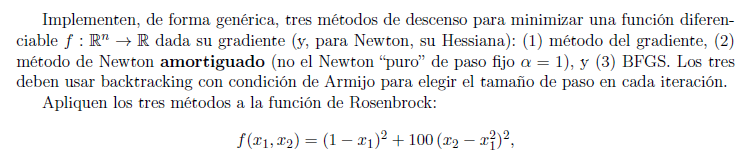

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizadores import OptimizadorNoLineal

## Verificación numérica del gradiente y hessiano calculado manual

In [2]:
def f(x):
    """Función de Rosenbrock."""
    x1, x2 = x
    return (1 - x1)**2 + 100*(x2 - x1**2)**2

def grad_f_manual(x):
    "Resultado del gradiente calculado manual."
    x1, x2 = x
    return np.array([
        -2*(1-x1) - 400*x1*(x2 - x1**2),
        200*(x2 - x1**2)
    ])

def hess_f_manual(x):
    """Resultado del hessiano calculado manual."""
    x1, x2 = x
    return np.array([
        [2 - 400*(x2 - x1**2) + 800*x1**2, -400*x1],
        [-400*x1, 200]
    ])

def grad_f_numerico(f, x, h=1e-5):
    """Verificación numérica del gradiente."""
    n = len(x)
    grad = np.zeros(n)
    for i in range(n):
        x_mas = x.copy(); x_mas[i] += h
        x_menos = x.copy(); x_menos[i] -= h
        grad[i] = (f(x_mas) - f(x_menos)) / (2*h)
    return grad

def hess_f_numerico(grad_func, x, h=1e-5):
    """Verificación numérica del hessiano."""
    n = len(x)
    hess = np.zeros((n, n))
    for j in range(n):
        x_mas = x.copy(); x_mas[j] += h
        x_menos = x.copy(); x_menos[j] -= h
        hess[:, j] = (grad_func(x_mas) - grad_func(x_menos)) / (2*h)
    return hess

# Verificación punto de partida
x0 = np.array([-1.2, 1.0])

print("Gradiente manual:", grad_f_manual(x0))
print("Gradiente numérico: ", grad_f_numerico(f, x0))

print("Hessiano manual:\n", hess_f_manual(x0))
print("Hessiano numérico:\n", hess_f_numerico(grad_f_manual, x0))

Gradiente manual: [-215.6  -88. ]
Gradiente numérico:  [-215.60000005  -88.        ]
Hessiano manual:
 [[1330.  480.]
 [ 480.  200.]]
Hessiano numérico:
 [[1330.00000005  480.        ]
 [ 480.          200.        ]]


## Implementación de los tres métodos de descenso (gradiente, newton amortiguado y BFGS)

In [3]:
# punto de partida
x0 = np.array([-1.2, 1.0])

# Método del gradiente
x_grad, f_grad, gradnorm_grad = OptimizadorNoLineal.optimizar(
    f, grad_f_manual, x0, metodo='gradiente'
)

# Newton amortiguado
x_newton, f_newton, gradnorm_newton = OptimizadorNoLineal.optimizar(
    f, grad_f_manual, x0, metodo='newton', hess_f=hess_f_manual
)

# BFGS
x_bfgs, f_bfgs, gradnorm_bfgs = OptimizadorNoLineal.optimizar(
    f, grad_f_manual, x0, metodo='bfgs'
)

print("Gradiente   -> iteraciones:", len(x_grad)-1, "| x_final:", x_grad[-1], "| f_final:", f_grad[-1])
print("Newton      -> iteraciones:", len(x_newton)-1, "| x_final:", x_newton[-1], "| f_final:", f_newton[-1])
print("BFGS        -> iteraciones:", len(x_bfgs)-1, "| x_final:", x_bfgs[-1], "| f_final:", f_bfgs[-1])

Gradiente   -> iteraciones: 1000 | x_final: [0.97277594 0.9460233 ] | f_final: 0.000748424735481543
Newton      -> iteraciones: 21 | x_final: [1. 1.] | f_final: 3.743975643139474e-21
BFGS        -> iteraciones: 34 | x_final: [1.         0.99999999] | f_final: 2.7456422309972502e-17


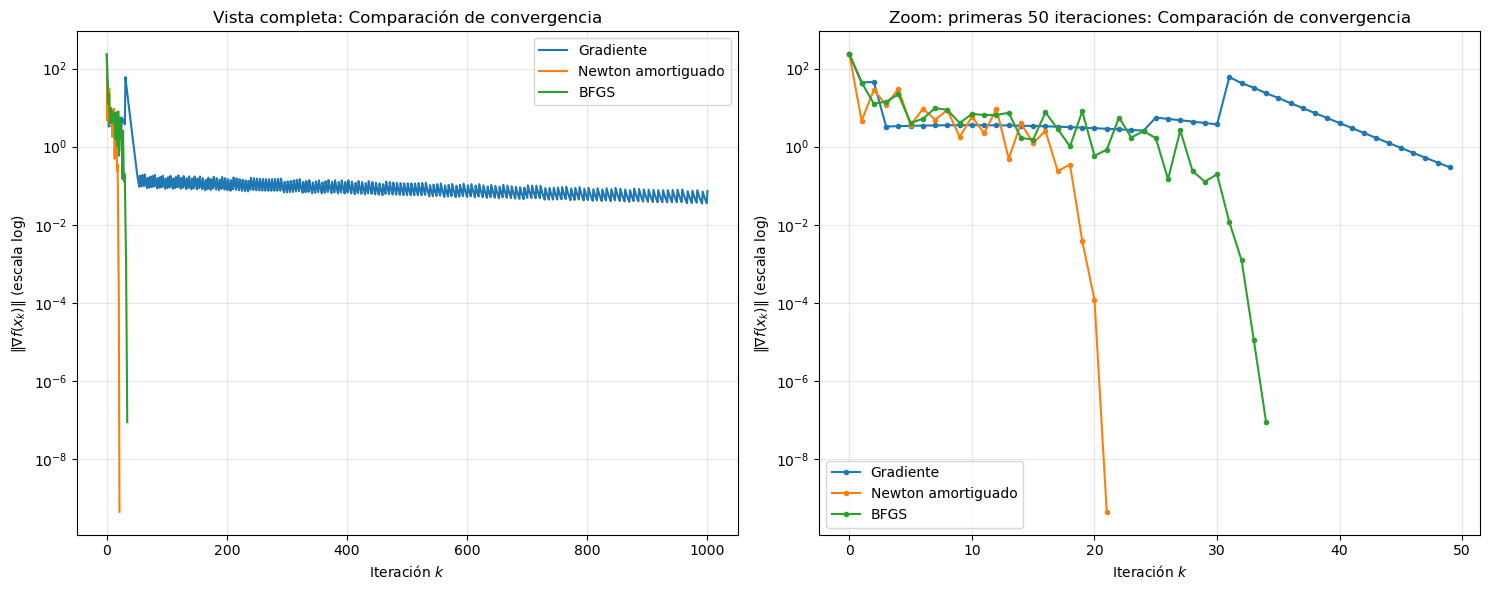

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Imagen de la izquierda: gráfica completa 
axes[0].semilogy(gradnorm_grad, label='Gradiente')
axes[0].semilogy(gradnorm_newton, label='Newton amortiguado')
axes[0].semilogy(gradnorm_bfgs, label='BFGS')
axes[0].set_xlabel('Iteración $k$')
axes[0].set_ylabel(r'$\|\nabla f(x_k)\|$ (escala log)')
axes[0].set_title('Vista completa: Comparación de convergencia')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Imagen de la derecha: zoom a las primeras iteraciones
n_zoom = 50
axes[1].semilogy(gradnorm_grad[:n_zoom], label='Gradiente', marker='.')
axes[1].semilogy(gradnorm_newton[:n_zoom], label='Newton amortiguado', marker='.')
axes[1].semilogy(gradnorm_bfgs[:n_zoom], label='BFGS', marker='.')
axes[1].set_xlabel('Iteración $k$')
axes[1].set_ylabel(r'$\|\nabla f(x_k)\|$ (escala log)')
axes[1].set_title(f'Zoom: primeras {n_zoom} iteraciones: Comparación de convergencia')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

De los resultados numéricos y de las gráficas de convergencia, se puede ver que el método del gradiente no logró converger dentro del máximo de iteraciones (1000), quedándose en una meseta oscilante y observandose un comportamiento de convergencia lineal. Por otro lado, el método de Newton amortiguado convergió en 21 iteraciones, mostrando una caída pronunciada en las últimas iteraciones, lo cual es consistente con su convergencia cuadrática. Por último, BFGS convergió en 34 iteraciones, más rápido que el gradiente pero más lento que Newton, un comportamiento intermedio que corresponde a su convergencia superlineal. Además, los tres métodos terminan acercándose al punto (1,1) y a f≈0 aproximadamente.